In [103]:
import fenics
import dolfin
from fenics import *
from hmm.stokes import StokesData, StokesHMMWrapper, HyperParams
from util.basis_scaled import *
from dolfin import *
import matplotlib.pyplot as plt
from util.plot_tools import remove_axes, remove_top_right_axes, plot_periodic
from mshr import *
import boundary_solvers.geometry as geom
import boundary_solvers.gauss_grid_2d as grd
from util.interp import PiecewiseInterp2D
import time

import pygmsh as pg
import dolfin as dl
import mshr as ms
import numpy as np
import matplotlib.pyplot as plt
import meshio
import gmsh

MESH_PATH = "/home/emastr/deep-micro-slip-model/data/mesh/"
figures_dir = "/home/emastr/deep-micro-slip-model/data/figures/"

First, we set up the FeniCS solvers.

In [104]:
# Sub domain for Periodic boundary condition
class PeriodicBoundary(SubDomain):
    def __init__(self, dom, y0):
        SubDomain.__init__(self)
        self.L = dom[0][1] - dom[0][0]
        self.dom = dom
        self.y0 = y0

    # Left boundary is "target domain" G
    def inside(self, x, on_boundary):
        return bool(near(x[0], self.dom[0][0]) and (not (near(x[1], self.dom[1][1]) or near(x[1], self.y0))) and on_boundary)
        #return bool(near(x[0], self.dom[0][0]) and on_boundary)# and (x[1] > self.y0) and (x[1] < self.dom[1][1]))
        #return bool(x[0]-data.dom[0][0] < DOLFIN_EPS and x[0]-data.dom[0][0] > -DOLFIN_EPS and on_boundary)

    # Map right boundary (H) to left boundary (G)
    def map(self, x, y):
        #if near(x[0], self.dom[0][1]) and (not near(x[1], self.dom[1][1]) and not near(x[1], self.y0)):
        y[0] = x[0] - self.L
        y[1] = x[1]

        

def create_mesh(mesh, cell_type, prune_z=False):
    cells = mesh.get_cells_type(cell_type)
    cell_data = mesh.get_cell_data("gmsh:physical", cell_type)
    points = mesh.points[:,:2] if prune_z else mesh.points
    out_mesh = meshio.Mesh(points=points, cells={cell_type: cells}, cell_data={"name_to_read":[cell_data]})
    return out_mesh

def fenicsSolve(data, info, roof_Nx=50, floor_Nx=50, resolution=10):      
    L = data.dom[0][1]-data.dom[0][0]
    W = data.dom[1][1]-data.dom[1][0]
    freq_g = info['freq_g']
    amp = info['amp']
    eval_pos = info['eval_pos']
    
    
    f = lambda t: data.f(t - 0.5*np.pi / 31) + eval_pos
    y0 = f(0)
    wall_Nx = int(roof_Nx * W/L)

    roof_x = np.linspace(data.dom[0][1], data.dom[0][0], roof_Nx)
    roof_y = data.dom[1][1] * np.ones(roof_Nx)

    inlet_x = np.ones(wall_Nx) * data.dom[0][0]
    inlet_y = np.linspace(data.dom[1][1], f(0), wall_Nx)

    floor_x = np.linspace(data.dom[0][0], data.dom[0][1], floor_Nx)
    floor_t = np.linspace(0, np.pi/2, floor_Nx)
    floor_y = f(floor_t)   
    
    outlet_x = np.ones(wall_Nx) * data.dom[0][1]
    outlet_y = np.linspace(f(np.pi/2), data.dom[1][1], wall_Nx)
    
    #Polygon(pts)
    with pg.geo.Geometry() as geom:
            pts_floor = [geom.add_point([x, y]) for x, y in zip(floor_x, floor_y)]
            pts_outlet = [pts_floor[-1]] + [geom.add_point([x, y]) for x, y in zip(outlet_x[1:], outlet_y[1:])]
            pts_roof =  [pts_outlet[-1]] + [geom.add_point([x, y]) for x, y in zip(roof_x[1:], roof_y[1:])]
            pts_inlet = [pts_roof[-1]] + [geom.add_point([x, y]) for x, y in zip(inlet_x[1:-1], inlet_y[1:-1])] + [pts_floor[0]]
            
            
            splines = []
            for pts in [pts_roof, pts_inlet, pts_floor, pts_outlet]:
                splines.append(geom.add_bspline(pts))
            for spline in splines:
                print(spline.points[0], spline.points[-1])
            domain = geom.add_curve_loop(splines)
            
     
            surf = geom.add_plane_surface(domain)
            geom.add_physical(surf, label='Inside')
            geom.add_physical(surf.curve_loop.curves, label='Dirichlet')
            #geom.add_physical(list_sum([inc.curve_loop.curves for inc in inclusions[1:]]), label='Roughness')
            
            
            c = resolution
            #a = np.log(res_max / res_min) / (self.R - self.r) * 2.
            geom.set_mesh_size_callback(lambda dim, tag, x, y, z, lc: c )
            
            
            mesh = geom.generate_mesh(dim=2)
            gmsh.write(f'{MESH_PATH}temp.msh')        
            mesh = meshio.read(f'{MESH_PATH}temp.msh')
            
            bdry = create_mesh(mesh, "line", True)
            dom_mesh = create_mesh(mesh, "triangle", True)
            
            meshio.write(f'{MESH_PATH}_volume_temp.xdmf', dom_mesh)
            meshio.write(f'{MESH_PATH}_boundary_temp.xdmf', bdry)
            
            file = dl.XDMFFile(f'{MESH_PATH}_volume_temp.xdmf')
            dom_mesh = dl.Mesh()
            file.read(dom_mesh)

            bdry_file = dl.XDMFFile(f'{MESH_PATH}_boundary_temp.xdmf')
            bdry_mesh = dl.Mesh()
            bdry_file.read(bdry_mesh)

            
    # Define the four boundaries + circle
    eps = 1e-5
    inflow = f'on_boundary && near(x[0], {data.dom[0][0]}) && (x[1] > {f(00.00/2)+eps})'
    outflow = f'on_boundary && near(x[0],{data.dom[0][1]}) && (x[1] > {f(np.pi/2)+eps})'
    roof = f'on_boundary && near(x[1],{data.dom[1][1]}, {DOLFIN_EPS})'
    walls = f'{inflow} || {outflow} || {roof}'
    floor = f'on_boundary && !({inflow} || {roof} || {outflow})'

    # Define the function spaces
    pb = PeriodicBoundary(data.dom, f(0))
    P2 = VectorElement(family='P', cell=triangle, degree=2)
    P1 = FiniteElement(family='P', cell=triangle, degree=1)
    P2P1 = P2 * P1
    W = FunctionSpace(dom_mesh, P2P1)#, constrained_domain=pb)
    U = W.sub(0)#extract_sub_space([0])        
    
    # Forces
    f = Constant((0,0))
    n = FacetNormal(dom_mesh)
    
    (u, p) = TrialFunctions(W)
    (v, q) = TestFunctions(W)

    # Boundary Conditions
    #bcu_roof = DirichletBC(U, Constant((1, 0)), roof)
    #bcu_roof = DirichletBC(U, Expression((f'{data.dom[1][1]} * (1 + (sin(2*pi*x[0]/{L})*0.4 + sin({freq_g}*2*pi*x[0]/{L})*0.6) * {amp}) ', '0'), degree=2), roof)
    bcu_roof = DirichletBC(U, Expression((f'pow((x[1]/{data.dom[1][1]-y0}), 2)', '0'), degree=2), walls)
    #dom[1][1]*(1 + (np.sin(2*np.pi * x / Lx)*0.4 + np.sin(freq_g*2*np.pi * x / Lx)*0.6) * amp)
    bcu_floor = DirichletBC(U, Constant((0, 0)), floor)
    bcu = [bcu_roof, bcu_floor]

    t = time.time()
    #F = dot(grad(u)*v, n)*ds - p*dot(v,n)*ds - inner(grad(u),grad(v))*dx + p*div(v)*dx+ dot(u,grad(q))*dx - dot(f ,v)*dx - dot(u, n)*q*ds
    F = - p*dot(v,n)*ds - inner(grad(u),grad(v))*dx + p*div(v)*dx+ dot(u,grad(q))*dx - dot(f ,v)*dx - dot(u, n)*q*ds
    a, L = lhs(F), rhs(F)
    print(f'Assembling time: {time.time()-t}')
    
    t = time.time()
    w = Function(W)
    solve(a == L, w, bcu)
    print(f'Solving time: {time.time()-t}')
    
    return w, W, dom_mesh
            

def extract_components(w, W):
    u=project(w[0], W.sub(0).sub(0).collapse())
    v=project(w[1], W.sub(0).sub(1).collapse())
    p=project(w[2], W.sub(1).collapse())
    return u, v, p

Next, we define hyper parameters for our HMM model.

In [105]:
data, info = StokesData.load_from_matlab(f"/home/emastr/deep-micro-slip-model/data/reference_2/run_{41}.mat")
eps = info['eps']
hyper = HyperParams(nMic = 5, n_refine=1, xDim=21, yDim=21, width=5.13*eps, height=5.13*eps, tol=1e-5, max_iter=30)
setup = StokesHMMWrapper(data, hyper)

dom = data.dom
eval_pos = info["eval_pos"]
eps = info["eps"]
nper = info["nper"]
Lx = info["Lx"]
bbox = info["bbox"]
Uc = info['Uc']
Vc = info['Vc']
Uyc = info['Uyc']

x = np.linspace(bbox[0][0],bbox[0][1],Uc.shape[0])
y = np.linspace(bbox[1][0],bbox[1][1],Uc.shape[1])
X,Y = np.meshgrid(x,y)

pwlerp = PiecewiseInterp2D(x, y, Uc)
pwlerp_dy = PiecewiseInterp2D(x, y, Uyc)
pwlerp_alpha = lambda x: -pwlerp(x, np.ones_like(x)*eval_pos) / pwlerp_dy(x, np.ones_like(x)*eval_pos)

In [106]:
# u,v,p define and project
w, W, omega = fenicsSolve(data, info, roof_Nx=400, floor_Nx=450, resolution=0.01)#wresolution=200) 
#w_h, W_h, omega_h = fenicsSolve(data, info, roof_Nx=50, floor_Nx=50, resolution=40)
w_h, W_h, omega_h = fenicsSolve(data, info, roof_Nx=400, floor_Nx=450, resolution=0.1)

<pygmsh Point object, ID 548, x = [1.0, 0.5, 0.0]> <pygmsh Point object, ID 947, x = [-1.0, 0.5, 0.0]>
<pygmsh Point object, ID 947, x = [-1.0, 0.5, 0.0]> <pygmsh Point object, ID 1, x = [-1.0, -0.012915496650148836, 0.0]>
<pygmsh Point object, ID 1, x = [-1.0, -0.012915496650148836, 0.0]> <pygmsh Point object, ID 450, x = [1.0, -0.01291549665014875, 0.0]>
<pygmsh Point object, ID 450, x = [1.0, -0.01291549665014875, 0.0]> <pygmsh Point object, ID 548, x = [1.0, 0.5, 0.0]>

Assembling time: 0.006247282028198242
Solving linear variational problem.
Solving time: 93.67787003517151
<pygmsh Point object, ID 548, x = [1.0, 0.5, 0.0]> <pygmsh Point object, ID 947, x = [-1.0, 0.5, 0.0]>
<pygmsh Point object, ID 947, x = [-1.0, 0.5, 0.0]> <pygmsh Point object, ID 1, x = [-1.0, -0.012915496650148836, 0.0]>
<pygmsh Point object, ID 1, x = [-1.0, -0.012915496650148836, 0.0]> <pygmsh Point object, ID 450, x = [1.0, -0.01291549665014875, 0.0]>
<pygmsh Point object, ID 450, x = [1.0, -0.0129154966501

Object cannot be plotted directly, projecting to piecewise linears.
Object cannot be plotted directly, projecting to piecewise linears.


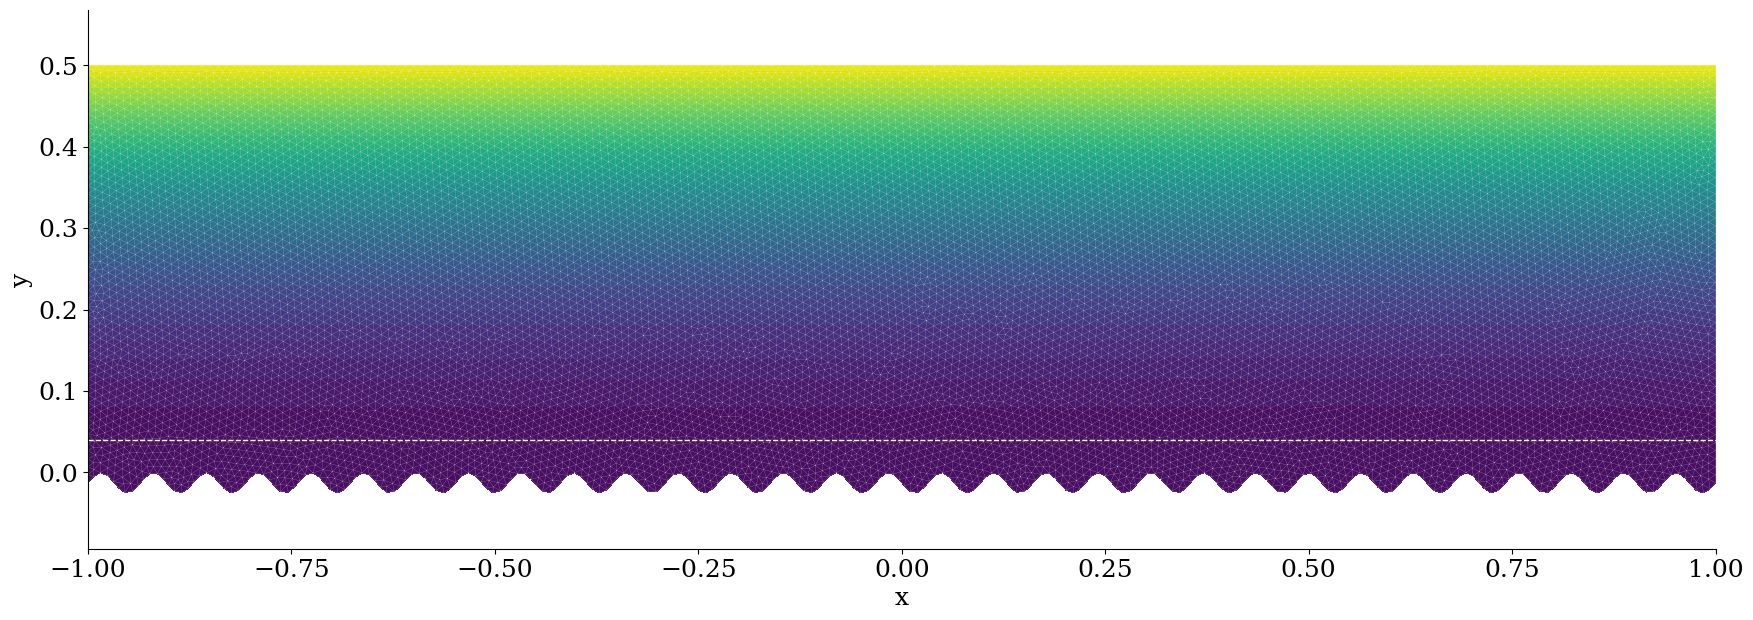

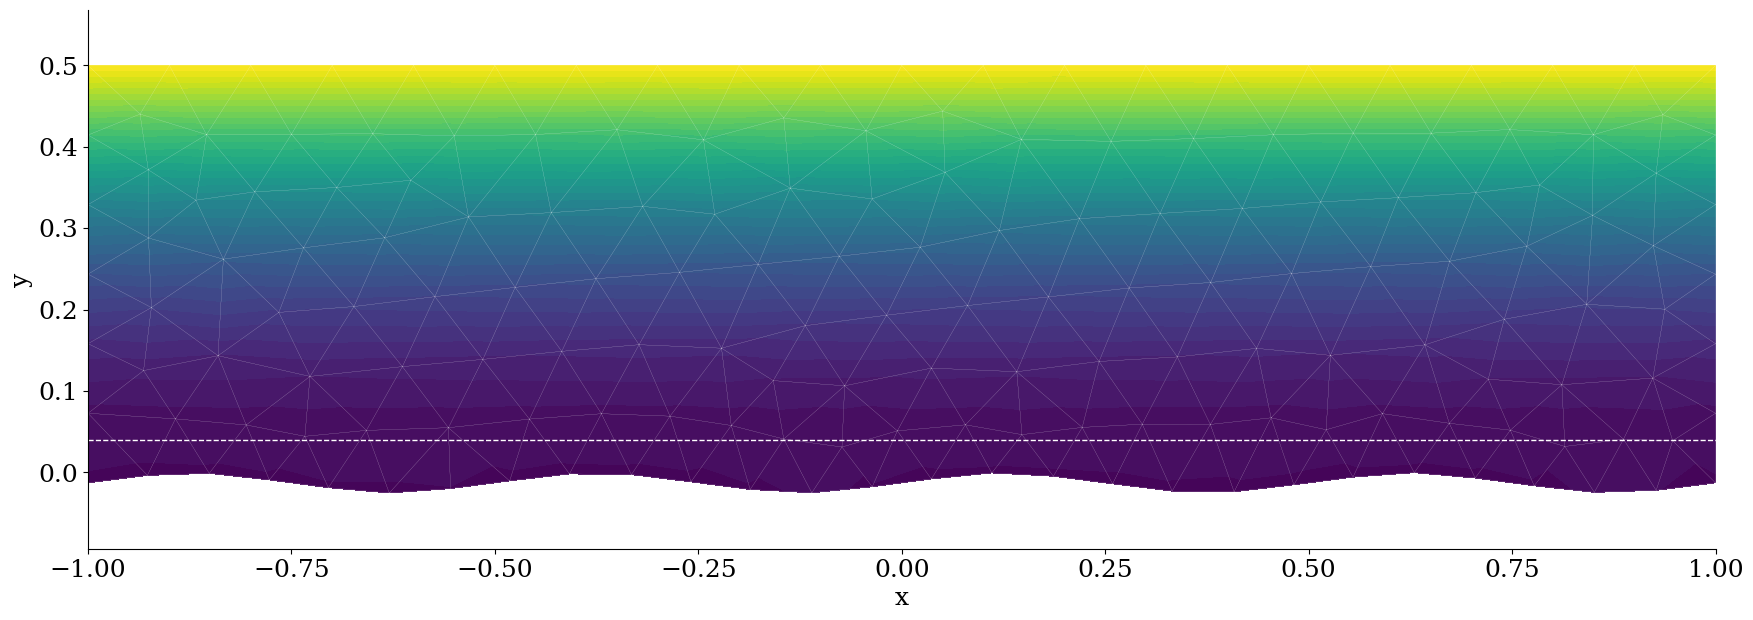

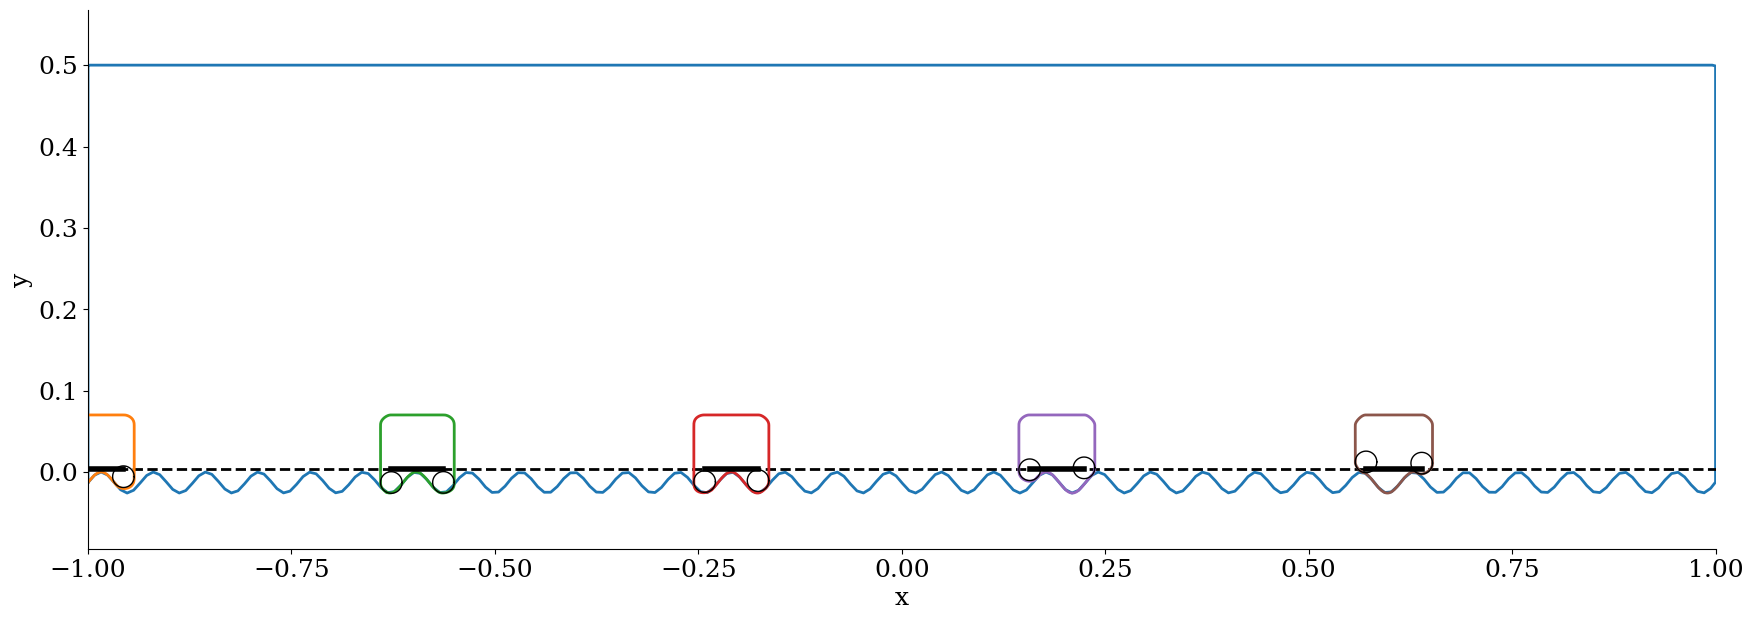

In [107]:
u, v, p = extract_components(w, W)
u_h, v_h, p_h = extract_components(w_h, W_h)

xval = np.linspace(data.dom[0][0], data.dom[0][1], 500)
yval0 = 0.04
yval = yval0 + xval * 0

def adjust_plot(ax):
    remove_top_right_axes(ax)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal')
    ax.set_xlim(data.dom[0])

plt.figure(figsize=(21,7))
plot((u**2 + v**2)**0.5)
plot(omega, color='white', linewidth=0.1)
plt.plot(xval, yval, 'white', linestyle='--', linewidth=1)
adjust_plot(plt.gca())

plt.figure(figsize=(21, 7))
plot((u_h**2 + v_h**2)**0.5)
plot(omega_h, color='white', linewidth=0.1)
plt.plot(xval, yval, 'white', linestyle='--', linewidth=1)
adjust_plot(plt.gca())

plt.figure(figsize=(21,7))
setup.hmm_problem.plot(plt.gca(), npts=1000)
adjust_plot(plt.gca())

We also plot the solutions along a line

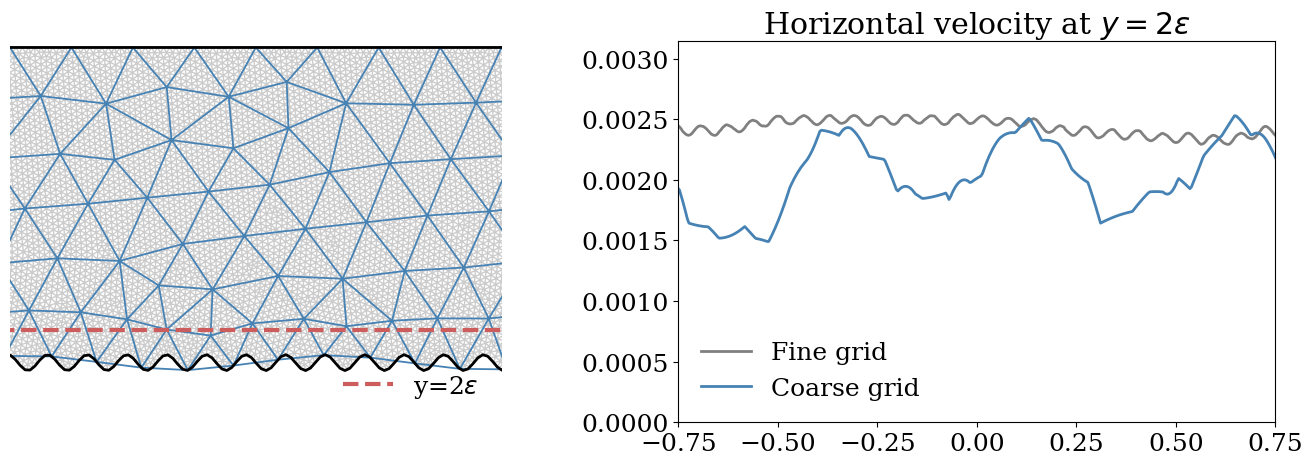

In [114]:
from boundary_solvers.geometry import MacroGeomGeneric
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8,8)
matplotlib.rcParams['font.size'] = 18
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2

def plot_line(xmin, xmax, func, N, **plotargs):
    x = np.linspace(xmin, xmax, N)
    plt.plot(x, func(x), **plotargs)


plt.figure(figsize=(14,5))


plt.subplot2grid((1,2), (0, 1), colspan=1)
yval0 = 2*eps
line_eval = info['eval_pos'] * 0
ufunc = lambda xs: np.array([u(x, yval0) for x in xs])
uhfunc = lambda xs: np.array([u_h(x, yval0) for x in xs])
ulerpfunc = lambda xs: pwlerp(xs, np.ones_like(xs)*yval0)

funcs = [ufunc, uhfunc]#, ulerpfunc]
labels = ['Fine grid', 'Coarse grid']#, 'BIM LERP']
color = ['grey', 'steelblue']
linestyle = ['-', '-']#, '-', '--']

N = 500
for f, l, c, s in zip(funcs, labels, color, linestyle):
    plot_line(data.dom[0][0], data.dom[0][1], f, N, color=c, label=l, linestyle=s)
    
ylim = plt.gca().get_ylim()
plt.ylim(0, ylim[1]*1.2)
plt.xlim(-0.75, 0.75)
#plt.xticks([np.pi*i/2 for i in range(5)], [f'$\pi${i/2}' for i in range(5)])
plt.legend(frameon=False)
plt.title("Horizontal velocity at $y=2\\epsilon$")


plt.subplot2grid((1,2), (0,0))
dl.plot(omega, linewidth=1, alpha=0.4)#, label="Fine grid")
dl.plot(omega_h, color="steelblue", linewidth=1.3)#, label="Coarse grid")
plt.xlim(-0.4, 0.4)
plt.ylim(-0.11, 0.51)
plt.plot(xval, yval, 'indianred', linestyle='--', linewidth=3, label=f"y=2$\\epsilon$")
plt.legend(frameon=False)
plt.axis("off")
#plt.suptitle("Homogenization via coarse grids")
data = setup.hmm_problem.data
geom = MacroGeomGeneric(data.f, data.df, data.ddf, data.dom, 1, 1)
geom.plot(plt.gca(), showpts=False, npts=1000, color="black", linewidth=2)        
plt.tight_layout()

plt.gcf().savefig(f"{figures_dir}homogenization_coarse_grids.pdf", bbox_inches='tight')